# Занятие 40. Практика: градиентный бустинг (~90 мин)

**Только для преподавателя. Не выдавать студентам.**

Эталон практики. Ячейку **«Дано»** не меняйте.

Главная модель — **GradientBoostingRegressor** (теория — занятие 39, `gradient_boosting_theory.ipynb`).

На `make_regression` настроим глубину, построим staged-кривую MAE и попробуем early stopping (пп. 4–9 теории).

Термины и определения — в теоретическом ноутбуке. Здесь только практика.

---
## Дано: синтетическая регрессия

900 объектов, 10 признаков — как в теории.

In [1]:
import numpy as np
from sklearn.datasets import make_regression

X, y = make_regression(
    n_samples=900, n_features=10, n_informative=6, noise=25, random_state=42
)
print('Объектов:', len(X))

Объектов: 900


---
## Задание 0. Split (~8 мин)

`train_test_split`, `GradientBoostingRegressor`, `RandomForestRegressor`, `mean_absolute_error`, `RANDOM_STATE=42`, 70/30.

**Критерий:** train/val.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error

RANDOM_STATE = 42
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE
)

---
## Задание 1. max_depth (~15 мин)

По п. 5. `max_depth` in `[1,2,4,7]`, `n_estimators=180`, `learning_rate=0.05`. Train и validation MAE.

**Критерий:** таблица 4 строк.

In [3]:
for depth in [1, 2, 4, 7]:
    m = GradientBoostingRegressor(
        n_estimators=180, learning_rate=0.05, max_depth=depth, random_state=RANDOM_STATE
    ).fit(X_train, y_train)
    tr = mean_absolute_error(y_train, m.predict(X_train))
    va = mean_absolute_error(y_val, m.predict(X_val))
    print(f'depth={depth} train MAE={tr:.1f} val MAE={va:.1f}')

depth=1 train MAE=41.2 val MAE=48.3
depth=2 train MAE=23.0 val MAE=35.8


depth=4 train MAE=10.5 val MAE=33.3


depth=7 train MAE=1.0 val MAE=43.4


---
## Задание 2. Staged curve (~18 мин)

По п. 7. Модель `n_estimators=350`, `max_depth=3`. Кривая train/validation MAE по `staged_predict`. Отметьте лучшее число деревьев.

**Критерий:** график + `best_n`.

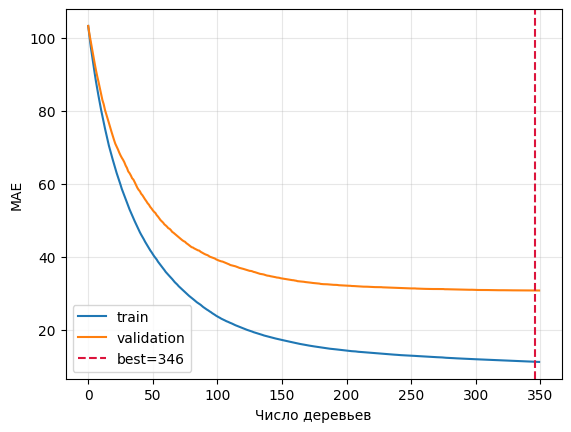

best_n: 346


In [4]:
import matplotlib.pyplot as plt

model = GradientBoostingRegressor(
    n_estimators=350, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
).fit(X_train, y_train)
train_mae, val_mae = [], []
for pt, pv in zip(model.staged_predict(X_train), model.staged_predict(X_val)):
    train_mae.append(mean_absolute_error(y_train, pt))
    val_mae.append(mean_absolute_error(y_val, pv))
best_n = int(np.argmin(val_mae)) + 1
plt.plot(train_mae, label='train')
plt.plot(val_mae, label='validation')
plt.axvline(best_n, color='crimson', ls='--', label=f'best={best_n}')
plt.xlabel('Число деревьев')
plt.ylabel('MAE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print('best_n:', best_n)

---
## Задание 3. learning_rate (~12 мин)

Сравните `learning_rate` 0.2 vs 0.05 при `n_estimators=150`, `max_depth=3`. Validation MAE.

**Критерий:** два числа.

In [5]:
for lr in [0.2, 0.05]:
    m = GradientBoostingRegressor(
        n_estimators=150, learning_rate=lr, max_depth=3, random_state=RANDOM_STATE
    ).fit(X_train, y_train)
    print(f'lr={lr} val MAE={mean_absolute_error(y_val, m.predict(X_val)):.1f}')

lr=0.2 val MAE=31.8
lr=0.05 val MAE=34.1


---
## Задание 4. Early stopping (~12 мин)

По п. 8–9. `validation_fraction=0.2`, `n_iter_no_change=15`. Сколько деревьев реально обучилось?

**Критерий:** `early.n_estimators_` < 350.

In [6]:
early = GradientBoostingRegressor(
    n_estimators=350, learning_rate=0.05, max_depth=3,
    validation_fraction=0.2, n_iter_no_change=15, tol=1e-4, random_state=RANDOM_STATE,
).fit(X_train, y_train)
print('Обучено деревьев:', early.n_estimators_)

Обучено деревьев: 350


---
## Задание 5. vs Random Forest (~12 мин)

По п. 13. `RandomForestRegressor(n_estimators=150)` — validation MAE vs лучший бустинг.

**Критерий:** два MAE.

In [7]:
rf = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
gb = GradientBoostingRegressor(
    n_estimators=best_n, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE
).fit(X_train, y_train)
print('RF val MAE:', round(mean_absolute_error(y_val, rf.predict(X_val)), 1))
print('GB val MAE:', round(mean_absolute_error(y_val, gb.predict(X_val)), 1))

RF val MAE: 43.2
GB val MAE: 30.8


---
## Задание 6. Остатки вручную (~12 мин)

По п. 3. На 4 точках из теории (`x=[1,2,5,8]`, `y=[10,14,18,30]`) посчитайте остатки после константного прогноза (среднее).

**Критерий:** массив residual.

In [8]:
x_demo = np.array([1., 2., 5., 8.])
y_demo = np.array([10., 14., 18., 30.])
pred0 = np.full_like(y_demo, y_demo.mean())
residual = y_demo - pred0
print('остатки:', residual)

остатки: [-8. -4.  0. 12.]


---
## Задание 7. Boosting vs bagging (~8 мин)

Markdown: одно предложение — чем boosting отличается от bagging (п. 12).

**Критерий:** последовательное исправление ошибок vs параллельные модели.

---
## Задание 8. Итог (~5 мин)

Чек-лист из п. 20 — отметьте 4 пункта, которые выполнили сегодня.

**Критерий:** markdown список.